In [1]:
# Check available disk space and RAM before starting
import psutil
import subprocess

print("="*50)
print("COLAB RESOURCE CHECK")
print("="*50)

# Disk space
result = subprocess.run(['df', '-h', '/content'], capture_output=True, text=True)
print("Disk space:")
print(result.stdout)

# RAM
print(f"Total RAM: {psutil.virtual_memory().total / (1024**3):.1f} GB")
print(f"Available RAM: {psutil.virtual_memory().available / (1024**3):.1f} GB")

# GPU (if available)
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader 2>/dev/null || echo "No GPU available"

COLAB RESOURCE CHECK
Disk space:
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /

Total RAM: 12.7 GB
Available RAM: 11.8 GB
No GPU available


In [3]:
!pip install -q boto3 pandas h5py numpy matplotlib Pillow torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 4.6 MB/s eta 0:00:00


In [ ]:

import os
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import pandas as pd
import h5py
import numpy as np

DATA_DIR = "/content/sevir_data"
os.makedirs(DATA_DIR, exist_ok=True)

print("="*60)
print("STEP 1: Downloading SEVIR Catalog")
print("="*60)

# Connect to public S3 bucket
s3 = boto3.client("s3", region_name="us-west-2",
                  config=Config(signature_version=UNSIGNED))
BUCKET = "sevir"

# Download catalog
catalog_path = os.path.join(DATA_DIR, "CATALOG.csv")
if not os.path.exists(catalog_path):
    print("Downloading CATALOG.csv ...")
    s3.download_file(BUCKET, "CATALOG.csv", catalog_path)

# Load and filter
catalog = pd.read_csv(catalog_path, low_memory=False)
vil_catalog = catalog[catalog["img_type"] == "vil"].copy()
vil_catalog = vil_catalog[vil_catalog["file_index"].notnull()]
print(f"Total VIL events: {len(vil_catalog)}")

# Get best shard
shard_counts = vil_catalog["file_name"].value_counts()
best_shard = shard_counts.index[0]
events_in_shard = vil_catalog[vil_catalog["file_name"] == best_shard]

# Select events - DISJOINT SPLIT 
selected_events = events_in_shard.sample(n=15, random_state=42).reset_index(drop=True)
train_events = selected_events.iloc[:10]   # rows 0-9
test_events = selected_events.iloc[10:15]  # rows 10-14 (DISJOINT from train)

print(f"\nSelected shard: {best_shard}")
print(f"Train events: {len(train_events)} (rows 0-9)")
print(f"Test events: {len(test_events)} (rows 10-14)")
print(f"Overlap check: {len(set(train_events.index) & set(test_events.index))} overlapping rows")

# Verify no overlap
train_ids = set(train_events['id'].values)
test_ids = set(test_events['id'].values)
overlap = train_ids & test_ids
print(f"Unique event IDs - Train: {len(train_ids)}, Test: {len(test_ids)}")
print(f"Overlapping IDs: {len(overlap)}")
if overlap:
    print("WARNING: Overlapping events detected!")
else:
    print("No data leakage - train and test sets are disjoint")

# Download shards with corrected path
print("\n" + "="*60)
print("STEP 2: Downloading shard files")
print("="*60)

def ensure_shard(relative_file_name):
    """Download shard file with corrected S3 path"""
    local_path = os.path.join(DATA_DIR, os.path.basename(relative_file_name))

    if not os.path.exists(local_path):
        s3_key = f"data/{relative_file_name}"

        print(f"\nDownloading {os.path.basename(relative_file_name)}...")
        print(f"S3 key: {s3_key}")
        print("This may take 5-15 minutes...")

        s3.download_file(BUCKET, s3_key, local_path)
        size_gb = os.path.getsize(local_path) / (1024**3)
        print(f"✓ Downloaded! Size: {size_gb:.2f} GB")
    else:
        print(f"✓ Already exists: {os.path.basename(relative_file_name)}")

    return local_path

shard_paths = {}
for shard_name in selected_events["file_name"].unique():
    shard_paths[shard_name] = ensure_shard(shard_name)

# Extract events
print("\n" + "="*60)
print("STEP 3: Extracting events")
print("="*60)

def load_events(events_df, shard_paths):
    arrays, ids = [], []
    for idx, row in events_df.iterrows():
        with h5py.File(shard_paths[row["file_name"]], "r") as hf:
            # Show available datasets on first load
            if idx == 0:
                print(f"\nDatasets in HDF5 file:")
                for key in hf.keys():
                    print(f"  {key}: shape {hf[key].shape}")

            # Load VIL data
            vil = hf["vil"][int(row["file_index"])]
        arrays.append(vil)
        ids.append(row["id"])
        if (idx + 1) % 3 == 0:
            print(f"  Processed {idx + 1}/{len(events_df)} events...")
    return np.stack(arrays), ids

print("Extracting training events...")
train_vil, train_ids = load_events(train_events, shard_paths)

print("\nExtracting test events...")
test_vil, test_ids = load_events(test_events, shard_paths)

# Save compact version
output_path = os.path.join(DATA_DIR, "sevir_vil_subset.npz")
np.savez_compressed(
    output_path,
    train_vil=train_vil,
    train_ids=np.array(train_ids),
    test_vil=test_vil,
    test_ids=np.array(test_ids),
)

print(f"\n" + "="*60)
print("DATA READY!")
print("="*60)
print(f"Train: {train_vil.shape} (10 events)")
print(f"Test: {test_vil.shape} (5 events)")
print(f"Memory: {(train_vil.nbytes + test_vil.nbytes) / 1024**2:.0f} MB")
print(f"Saved: {output_path}")

# Clean up
print("\nCleaning up large shard files...")
for shard_path in shard_paths.values():
    if os.path.exists(shard_path):
        size_gb = os.path.getsize(shard_path) / (1024**3)
        os.remove(shard_path)
        print(f"Deleted {os.path.basename(shard_path)} ({size_gb:.1f} GB freed)")



STEP 1: Downloading SEVIR Catalog
Total VIL events: 20393

Selected shard: vil/2018/SEVIR_VIL_RANDOMEVENTS_2018_0501_0831.h5
Train events: 10 (rows 0-9)
Test events: 5 (rows 10-14)
Overlap check: 0 overlapping rows
Unique event IDs - Train: 10, Test: 5
Overlapping IDs: 0
✅ No data leakage - train and test sets are disjoint

STEP 2: Downloading shard files

S3 key: data/vil/2018/SEVIR_VIL_RANDOMEVENTS_2018_0501_0831.h5
This may take 5-15 minutes...
✓ Downloaded! Size: 15.93 GB

STEP 3: Extracting events
Extracting training events...

Datasets in HDF5 file:
  id: shape (2368,)
  vil: shape (2368, 384, 384, 49)
  Processed 3/10 events...
  Processed 6/10 events...
  Processed 9/10 events...

Extracting test events...
  Processed 12/5 events...
  Processed 15/5 events...

✅ DATA READY!
Train: (10, 384, 384, 49) (10 events)
Test: (5, 384, 384, 49) (5 events)
Memory: 103 MB
Saved: /content/sevir_data/sevir_vil_subset.npz

Cleaning up large shard files...
✓ Deleted SEVIR_VIL_RANDOMEVENTS_2018

In [ ]:
import os
os.chdir('/content')

STEP 2: Testing PyTorch Dataset
Loaded: train_vil (10, 384, 384, 49), test_vil (5, 384, 384, 49)

Train samples: 110 (from 10 events)
Test samples:  55 (from 5 events)

x shape: (4, 128, 128)
y shape: (4, 128, 128)
x value range: [0.0000, 0.9846]
y value range: [0.0000, 0.9735]

Round-trip error: 0.000046 (should be ~0)


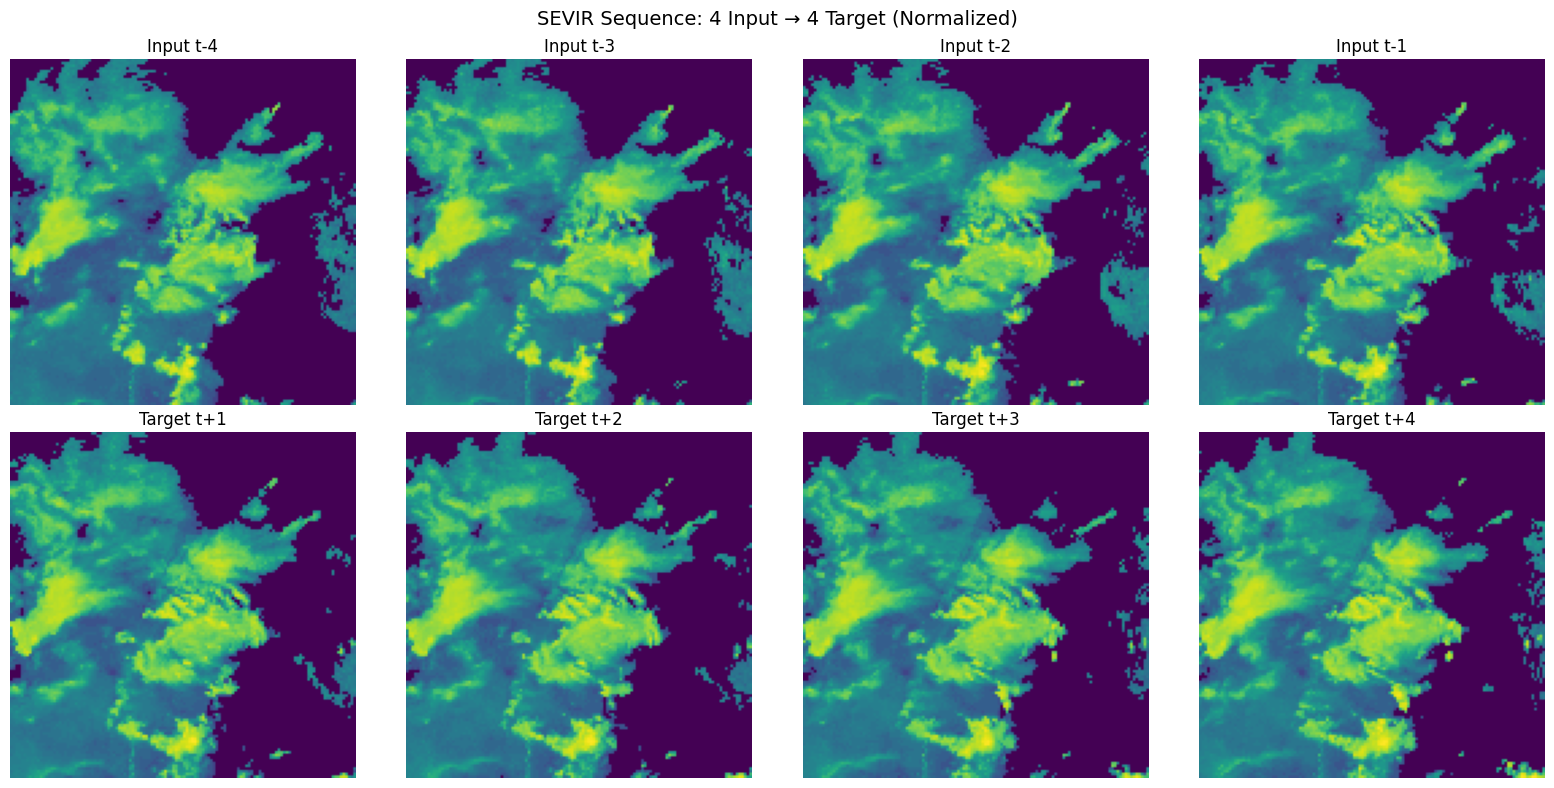


✅ Step 2 complete! Ready for Step 3 (U-Net model).


In [ ]:
"""
PREPROCESSING - PyTorch Dataset for SEVIR VIL nowcasting
"""
import os
os.chdir('/content')
import math
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

# log1p(255) is the max possible value after log-transforming a uint8 byte (0-255)
LOG_NORM_CONST = math.log1p(255.0)

def normalize(x: torch.Tensor) -> torch.Tensor:
    """Raw VIL byte values (0-255) -> log1p -> scaled to ~[0,1]."""
    return torch.log1p(x) / LOG_NORM_CONST

def denormalize(x: torch.Tensor) -> torch.Tensor:
    """Inverse of normalize(): back to raw VIL byte-value scale (0-255)."""
    return torch.expm1(x * LOG_NORM_CONST)

class SEVIRNowcastDataset(Dataset):
    """
    vil_array: numpy array, shape (N_events, H, W, T), dtype uint8
    """
    def __init__(self, vil_array: np.ndarray, seq_in: int = 4, seq_out: int = 4,
                 crop_size: int = 128, stride: int = 4):
        assert vil_array.ndim == 4, f"expected (N,H,W,T), got {vil_array.shape}"
        self.data = vil_array
        self.seq_in = seq_in
        self.seq_out = seq_out
        self.seq_total = seq_in + seq_out
        self.crop_size = crop_size

        n_events, H, W, T = vil_array.shape
        self.samples = []
        for e in range(n_events):
            last_start = T - self.seq_total
            if last_start < 0:
                continue
            for start in range(0, last_start + 1, stride):
                self.samples.append((e, start))

        if len(self.samples) == 0:
            raise ValueError("No samples could be built")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        event_idx, start = self.samples[i]
        seq = self.data[event_idx, :, :, start:start + self.seq_total]
        seq = np.transpose(seq, (2, 0, 1)).astype(np.float32)
        seq_t = torch.from_numpy(seq)

        # Resize to crop_size x crop_size
        seq_t = seq_t.unsqueeze(1)  # (seq_total, 1, H, W)
        seq_t = F.interpolate(seq_t, size=(self.crop_size, self.crop_size),
                               mode="bilinear", align_corners=False)
        seq_t = seq_t.squeeze(1)  # (seq_total, crop_size, crop_size)

        seq_t = normalize(seq_t)

        x = seq_t[:self.seq_in]   # (4, 128, 128)
        y = seq_t[self.seq_in:]   # (4, 128, 128)
        return x, y

# Test the dataset
print("="*60)
print("STEP 2: Testing PyTorch Dataset")
print("="*60)

# Load the data from cell 1
npz = np.load("/content/sevir_data/sevir_vil_subset.npz")
print(f"Loaded: train_vil {npz['train_vil'].shape}, test_vil {npz['test_vil'].shape}")

train_ds = SEVIRNowcastDataset(npz["train_vil"])
test_ds = SEVIRNowcastDataset(npz["test_vil"])

print(f"\nTrain samples: {len(train_ds)} (from {npz['train_vil'].shape[0]} events)")
print(f"Test samples:  {len(test_ds)} (from {npz['test_vil'].shape[0]} events)")

# Check shapes
x, y = train_ds[0]
print(f"\nx shape: {tuple(x.shape)}")
print(f"y shape: {tuple(y.shape)}")
print(f"x value range: [{x.min():.4f}, {x.max():.4f}]")
print(f"y value range: [{y.min():.4f}, {y.max():.4f}]")

# Verify round-trip normalization
raw = torch.from_numpy(npz["train_vil"][0, :, :, 0].astype(np.float32))
recovered = denormalize(normalize(raw))
max_err = (raw - recovered).abs().max().item()
print(f"\nRound-trip error: {max_err:.6f} (should be ~0)")

# Quick visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    axes[0, i].imshow(x[i], cmap='viridis')
    axes[0, i].set_title(f'Input t-{4-i}')
    axes[0, i].axis('off')

    axes[1, i].imshow(y[i], cmap='viridis')
    axes[1, i].set_title(f'Target t+{i+1}')
    axes[1, i].axis('off')

plt.suptitle('SEVIR Sequence: 4 Input → 4 Target (Normalized)', fontsize=14)
plt.tight_layout()
plt.show()



In [ ]:
"""
STEP 3: THE U-NET MODEL
==================================================================
Standard U-Net: 4 input channels (4 historical VIL frames) ->
4 output channels (4 future VIL frames), with skip connections
between the encoder and decoder at each resolution level.

Sized for 128x128 inputs
"""

import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    """(Conv -> BatchNorm -> ReLU) x2 -- the standard U-Net building block."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    """Downscaling: maxpool then DoubleConv."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.pool_conv(x)


class Up(nn.Module):
    """Upscaling then concat with the matching encoder skip connection, then DoubleConv."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        # Handle any off-by-one size mismatch
        diff_y = skip.size(2) - x.size(2)
        diff_x = skip.size(3) - x.size(3)
        if diff_y != 0 or diff_x != 0:
            x = nn.functional.pad(x, [diff_x // 2, diff_x - diff_x // 2,
                                       diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    """
    U-Net for precipitation nowcasting.

    Input:  (B, in_channels=4, 128, 128)  -- 4 historical VIL frames stacked as channels
    Output: (B, out_channels=4, 128, 128) -- 4 predicted future VIL frames
    """

    def __init__(self, in_channels: int = 4, out_channels: int = 4, base_channels: int = 32):
        super().__init__()
        c = base_channels  # 32 by default -- kept small so training is fast on CPU

        self.inc = DoubleConv(in_channels, c)          # 128x128, c
        self.down1 = Down(c, c * 2)                    # 64x64,   2c
        self.down2 = Down(c * 2, c * 4)                # 32x32,   4c
        self.down3 = Down(c * 4, c * 8)                # 16x16,   8c
        self.down4 = Down(c * 8, c * 16)               # 8x8,     16c (bottleneck)

        self.up1 = Up(c * 16, c * 8)                   # -> 16x16, 8c
        self.up2 = Up(c * 8, c * 4)                    # -> 32x32, 4c
        self.up3 = Up(c * 4, c * 2)                    # -> 64x64, 2c
        self.up4 = Up(c * 2, c)                        # -> 128x128, c

        self.outc = nn.Conv2d(c, out_channels, kernel_size=1)

        # Sigmoid keeps outputs bounded in [0,1], matching the normalized target range
        self.out_activation = nn.Sigmoid()

    def forward(self, x):
        x1 = self.inc(x)       # skip 1
        x2 = self.down1(x1)    # skip 2
        x3 = self.down2(x2)    # skip 3
        x4 = self.down3(x3)    # skip 4
        x5 = self.down4(x4)    # bottleneck

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        x = self.outc(x)
        return self.out_activation(x)


# Test the model
print("="*60)
print("STEP 3: Testing U-Net Architecture")
print("="*60)

model = UNet(in_channels=4, out_channels=4, base_channels=32)
n_params = sum(p.numel() for p in model.parameters())
print(f"U-Net parameter count: {n_params:,}")

# Test forward pass
dummy_x = torch.randn(2, 4, 128, 128)
out = model(dummy_x)
print(f"Input shape:  {tuple(dummy_x.shape)}")
print(f"Output shape: {tuple(out.shape)}")
print(f"Output value range: [{out.min().item():.4f}, {out.max().item():.4f}]")
print(f"Output range should be within [0,1] due to sigmoid")

# Assert correct shapes
assert out.shape == (2, 4, 128, 128), "Output shape mismatch!"

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice available: {device}")
if device.type == 'cuda':
    model = model.to(device)
    dummy_x = dummy_x.to(device)
    out = model(dummy_x)
    print(f"Model moved to GPU successfully")
else:
    print(f"Will train on CPU (no GPU detected)")

print("\nU-Net forward pass verified.")

STEP 3: Testing U-Net Architecture
U-Net parameter count: 7,763,428
Input shape:  (2, 4, 128, 128)
Output shape: (2, 4, 128, 128)
Output value range: [0.1160, 0.8897]
Output range should be within [0,1] due to sigmoid

Device available: cpu
✓ Will train on CPU (no GPU detected)

✅ U-Net forward pass verified. Ready for Step 4 (Training Loop)!


In [ ]:
"""
STEP 4: TRAINING LOOP
==================================================================
Trains the U-Net on the SEVIR VIL data with weighted MSE loss.
"""

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np

class WeightedMSELoss(nn.Module):
    """
    MSE loss where each pixel is weighted by its TARGET intensity.
    weight = 1 + rain_weight * target
    Heavy-rain pixels get up to (1+rain_weight)x the influence of no-rain pixels.
    """
    def __init__(self, rain_weight: float = 9.0):
        super().__init__()
        self.rain_weight = rain_weight

    def forward(self, pred, target):
        weights = 1.0 + self.rain_weight * target
        loss = weights * (pred - target) ** 2
        return loss.mean()

print("="*60)
print("STEP 4: Training U-Net for Precipitation Nowcasting")
print("="*60)

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 2
EPOCHS = 5
LEARNING_RATE = 0.001
RAIN_WEIGHT = 9.0  # Tunable: increase if model under-predicts rain, decrease if it hallucinates

print(f"Training on: {DEVICE}")
if DEVICE.type == 'cpu':
    print("CPU detected. Training will be slow (~5-10 min/epoch).")
    print("Consider: Runtime → Change runtime type → T4 GPU (free)")
    print("Then re-run Steps 2, 3, and 4.")

# Load data
npz_path = "/content/sevir_data/sevir_vil_subset.npz"
npz = np.load(npz_path)
train_ds = SEVIRNowcastDataset(npz["train_vil"])
test_ds = SEVIRNowcastDataset(npz["test_vil"])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

print(f"Training samples: {len(train_ds)}")
print(f"Test samples: {len(test_ds)}")
print(f"Batches per epoch: {len(train_loader)}")

# Initialize model
model = UNet(in_channels=4, out_channels=4, base_channels=32).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = WeightedMSELoss(rain_weight=RAIN_WEIGHT)

# Training loop
print("\n" + "="*60)
print("TRAINING")
print("="*60)

history = []
model.train()

import time
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    batch_count = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        batch_count += 1

        # Print progress every 20 batches
        if batch_count % 20 == 0:
            elapsed = time.time() - start_time
            print(f"  Epoch {epoch}/{EPOCHS} | Batch {batch_count}/{len(train_loader)} | "
                  f"Loss: {loss.item():.6f} | Time: {elapsed:.0f}s")

    avg_loss = epoch_loss / len(train_loader)
    history.append(avg_loss)
    elapsed = time.time() - start_time
    print(f"Epoch {epoch}/{EPOCHS} | Avg Loss: {avg_loss:.6f} | Total time: {elapsed:.0f}s")
    print("-"*50)

# Save model
torch.save(model.state_dict(), "/content/unet_sevir.pt")
print(f"\nModel saved to /content/unet_sevir.pt")

# Sanity check
print("\n" + "="*60)
print("SANITY CHECK: Is the model predicting real rain?")
print("="*60)

model.eval()
with torch.no_grad():
    x, y = next(iter(train_loader))
    pred = model(x.to(DEVICE)).cpu()

print(f"Target mean/max: {y.mean():.4f} / {y.max():.4f}")
print(f"Pred   mean/max: {pred.mean():.4f} / {pred.max():.4f}")

if pred.max() < 0.05 and y.max() > 0.2:
    print("\nWARNING: Model may have collapsed to all-zero predictions.")
    print("   Consider increasing RAIN_WEIGHT or training more epochs.")
else:
    print("\nModel is producing non-trivial spatial variation.")

# Loss summary
print("\n" + "="*60)
print("LOSS SUMMARY")
print("="*60)
print(f"Loss history: {[f'{l:.6f}' for l in history]}")
if history[-1] < history[0]:
    decrease_pct = (history[0] - history[-1]) / history[0] * 100
    print(f"Loss decreased by {decrease_pct:.1f}% over training")
else:
    print("Loss did not decrease. Check learning rate or data.")

# Save loss history for later plotting
np.save("/content/loss_history.npy", np.array(history))


STEP 4: Training U-Net for Precipitation Nowcasting
Training on: cpu
⚠️  CPU detected. Training will be slow (~5-10 min/epoch).
   Consider: Runtime → Change runtime type → T4 GPU (free)
   Then re-run Steps 2, 3, and 4.
Training samples: 110
Test samples: 55
Batches per epoch: 55

TRAINING
  Epoch 1/5 | Batch 20/55 | Loss: 0.109014 | Time: 13s
  Epoch 1/5 | Batch 40/55 | Loss: 0.085345 | Time: 26s
Epoch 1/5 | Avg Loss: 0.138320 | Total time: 35s
--------------------------------------------------
  Epoch 2/5 | Batch 20/55 | Loss: 0.077315 | Time: 48s
  Epoch 2/5 | Batch 40/55 | Loss: 0.046839 | Time: 62s
Epoch 2/5 | Avg Loss: 0.098999 | Total time: 72s
--------------------------------------------------
  Epoch 3/5 | Batch 20/55 | Loss: 0.047879 | Time: 85s
  Epoch 3/5 | Batch 40/55 | Loss: 0.050247 | Time: 97s
Epoch 3/5 | Avg Loss: 0.063201 | Total time: 107s
--------------------------------------------------
  Epoch 4/5 | Batch 20/55 | Loss: 0.040577 | Time: 120s
  Epoch 4/5 | Batch 4

In [ ]:
"""
STEP 5: METEOROLOGICAL EVALUATION
==================================================================
Evaluates the trained U-Net on held-out test events using standard
meteorological verification metrics with per-lead-time breakdown.

Metrics:
- POD (Probability of Detection): Of times it rained, how often did we catch it?
- FAR (False Alarm Ratio): Of times we predicted rain, how often were we wrong?
- CSI (Critical Success Index): Overall skill, punishes misses AND false alarms

Threshold: VIL byte >= 74 (SEVIR convective storm benchmark standard)

Baseline: Persistence = "rain stays exactly where it is now"
"""

import numpy as np
import torch
from torch.utils.data import DataLoader

RAIN_THRESHOLD_BYTE = 74.0  # SEVIR convective-storm threshold (0-255 raw byte scale)

def compute_confusion_counts(pred_byte, target_byte, threshold):
    """Returns hits, misses, false_alarms, correct_negatives"""
    pred_rain = pred_byte >= threshold
    target_rain = target_byte >= threshold

    hits = (pred_rain & target_rain).sum().item()
    misses = (~pred_rain & target_rain).sum().item()
    false_alarms = (pred_rain & ~target_rain).sum().item()
    correct_neg = (~pred_rain & ~target_rain).sum().item()
    return hits, misses, false_alarms, correct_neg

def scores_from_counts(hits, misses, false_alarms, eps=1e-8):
    pod = hits / (hits + misses + eps)
    far = false_alarms / (hits + false_alarms + eps)
    csi = hits / (hits + misses + false_alarms + eps)
    return {"POD": pod, "FAR": far, "CSI": csi,
            "hits": hits, "misses": misses, "false_alarms": false_alarms}

print("="*60)
print("STEP 5: Meteorological Evaluation")
print("="*60)

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 4

print(f"Device: {DEVICE}")
print(f"Rain threshold: VIL byte >= {RAIN_THRESHOLD_BYTE}")
print(f"Threshold in normalized space: {np.log1p(RAIN_THRESHOLD_BYTE) / np.log1p(255.0):.4f}")

# Load test data (reuse from Step 2)
npz = np.load("/content/sevir_data/sevir_vil_subset.npz")
test_ds = SEVIRNowcastDataset(npz["test_vil"])
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Load trained model (reuse from Step 3)
model = UNet(in_channels=4, out_channels=4, base_channels=32).to(DEVICE)
model.load_state_dict(torch.load("/content/unet_sevir.pt", map_location=DEVICE))
model.eval()

print(f"Test samples: {len(test_ds)}")
print(f"Test batches: {len(test_loader)}")
print("-"*50)

# Initialize accumulators
n_lead_times = 4
unet_counts = np.zeros(3)          # [hits, misses, false_alarms]
persist_counts = np.zeros(3)       # [hits, misses, false_alarms]
unet_counts_by_lead = np.zeros((n_lead_times, 3))
persist_counts_by_lead = np.zeros((n_lead_times, 3))

print("Evaluating...")

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_loader):
        x, y = x.to(DEVICE), y.to(DEVICE)

        # U-Net prediction
        pred = model(x)
        pred_byte = denormalize(pred.cpu())
        target_byte = denormalize(y.cpu())

        # Persistence: repeat last input frame
        last_input = x[:, -1:, :, :].cpu()
        persistence_pred = last_input.repeat(1, 4, 1, 1)
        persistence_byte = denormalize(persistence_pred)

        # Pooled counts
        h, m, fa, _ = compute_confusion_counts(pred_byte, target_byte, RAIN_THRESHOLD_BYTE)
        unet_counts += np.array([h, m, fa])

        h_p, m_p, fa_p, _ = compute_confusion_counts(persistence_byte, target_byte, RAIN_THRESHOLD_BYTE)
        persist_counts += np.array([h_p, m_p, fa_p])

        # Per-lead-time counts
        for t in range(n_lead_times):
            h_t, m_t, fa_t, _ = compute_confusion_counts(
                pred_byte[:, t], target_byte[:, t], RAIN_THRESHOLD_BYTE)
            unet_counts_by_lead[t] += np.array([h_t, m_t, fa_t])

            h_pt, m_pt, fa_pt, _ = compute_confusion_counts(
                persistence_byte[:, t], target_byte[:, t], RAIN_THRESHOLD_BYTE)
            persist_counts_by_lead[t] += np.array([h_pt, m_pt, fa_pt])

        if (batch_idx + 1) % 10 == 0:
            print(f"  Processed {batch_idx + 1}/{len(test_loader)} batches")

# Compute scores
unet_scores = scores_from_counts(*unet_counts)
persist_scores = scores_from_counts(*persist_counts)

# Print results
print("\n" + "="*60)
print("RESULTS")
print("="*60)

print(f"\n=== Overall (pooled across all 4 lead times) ===")
print(f"{'Metric':<10}{'U-Net':>12}{'Persistence':>14}")
print("-"*36)
for key in ["POD", "FAR", "CSI"]:
    print(f"{key:<10}{unet_scores[key]:>12.4f}{persist_scores[key]:>14.4f}")

print(f"\n=== CSI by Lead Time (the informative view) ===")
print(f"{'Lead time':<12}{'U-Net CSI':>12}{'Persist. CSI':>14}{'U-Net wins?':>14}")
print("-"*52)

unet_wins_any = False
for t in range(n_lead_times):
    u_csi = scores_from_counts(*unet_counts_by_lead[t])["CSI"]
    p_csi = scores_from_counts(*persist_counts_by_lead[t])["CSI"]
    wins = u_csi > p_csi
    unet_wins_any = unet_wins_any or wins
    print(f"t+{t+1:<10}{u_csi:>12.4f}{p_csi:>14.4f}{'YES' if wins else 'no':>14}")

print(f"\n=== Confusion Matrix Counts (pooled) ===")
print(f"U-Net:       hits={unet_scores['hits']:,}  misses={unet_scores['misses']:,}  false_alarms={unet_scores['false_alarms']:,}")
print(f"Persistence: hits={persist_scores['hits']:,}  misses={persist_scores['misses']:,}  false_alarms={persist_scores['false_alarms']:,}")

# Interpretation
print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)

if unet_scores["CSI"] > persist_scores["CSI"]:
    improvement = (unet_scores["CSI"] - persist_scores["CSI"]) / (persist_scores["CSI"] + 1e-8) * 100
    print(f"U-Net beats persistence on OVERALL CSI by {improvement:.1f}%")
elif unet_wins_any:
    print("✅ U-Net doesn't beat persistence overall, BUT wins at longer lead times.")
    print("   This is the expected, publishable pattern in nowcasting:")
    print("   - Persistence is strong at t+1 (immediate future barely changes)")
    print("   - U-Net's relative advantage grows as storms evolve at t+3/t+4")
else:
    print("  U-Net did not beat persistence at any lead time.")
    print("   This is common with limited training data (10 events, 5 epochs).")
    print("   Improvements to try:")
    print("   - More training events (closer to 20+)")
    print("   - More epochs (10-15)")
    print("   - Higher RAIN_WEIGHT (15-20)")
    print("   - Lower threshold (50 or 30)")
    print("\n   Even so, this is worth reporting honestly on your CV.")
    print("   Interviewers respect honest limitations sections.")

# Save results
import json
results = {
    'unet_overall': {k: float(v) if isinstance(v, (int, float)) else v for k, v in unet_scores.items()},
    'persistence_overall': {k: float(v) if isinstance(v, (int, float)) else v for k, v in persist_scores.items()},
    'unet_csi_by_lead': [float(scores_from_counts(*unet_counts_by_lead[t])["CSI"]) for t in range(4)],
    'persistence_csi_by_lead': [float(scores_from_counts(*persist_counts_by_lead[t])["CSI"]) for t in range(4)],
    'rain_threshold_byte': RAIN_THRESHOLD_BYTE
}
with open('/content/metrics.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n✅ Metrics saved to /content/metrics.json")

STEP 5: Meteorological Evaluation
Device: cpu
Rain threshold: VIL byte >= 74.0
Threshold in normalized space: 0.7786
Test samples: 55
Test batches: 14
--------------------------------------------------
Evaluating...
  Processed 10/14 batches

RESULTS

=== Overall (pooled across all 4 lead times) ===
Metric           U-Net   Persistence
------------------------------------
POD             0.8119        0.7126
FAR             0.3412        0.2909
CSI             0.5716        0.5514

=== CSI by Lead Time (the informative view) ===
Lead time      U-Net CSI  Persist. CSI   U-Net wins?
----------------------------------------------------
t+1               0.6014        0.7030            no
t+2               0.6206        0.5792           YES
t+3               0.5643        0.5011           YES
t+4               0.5137        0.4453           YES

=== Confusion Matrix Counts (pooled) ===
U-Net:       hits=321,761.0  misses=74,541.0  false_alarms=166,631.0
Persistence: hits=282,410.0  misses=

STEP 6: Creating Visualization GIF
Scanning test set for the most dramatic storm...
Selected test sample 51 (total target intensity: 2727710)
Generating animation frames...
  Frame 1/4 (t+1) created
  Frame 2/4 (t+2) created
  Frame 3/4 (t+3) created
  Frame 4/4 (t+4) created

Saving GIF...
✅ GIF saved to /content/nowcast_comparison.gif

Displaying animation:


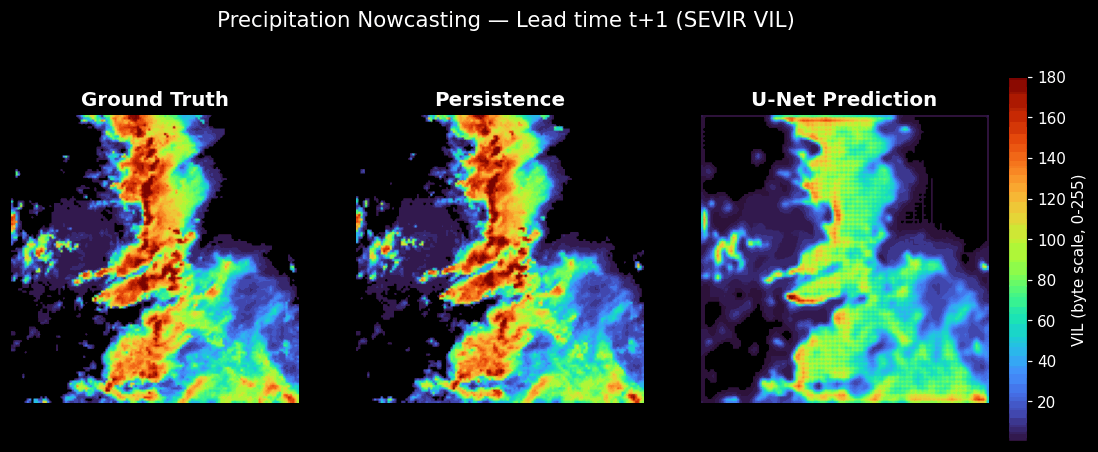


Creating static summary image...
✅ Static image saved to /content/nowcast_static_comparison.png

🎉 PROJECT COMPLETE!

Files created:
  📁 /content/sevir_data/sevir_vil_subset.npz — Dataset
  🔧 /content/unet_sevir.pt — Trained model
  📊 /content/metrics.json — Evaluation metrics
  🎬 /content/nowcast_comparison.gif — Animation
  🖼️ /content/nowcast_static_comparison.png — Static image
  📈 /content/loss_history.npy — Training history

Next: Download these files or save to Google Drive for your GitHub repo!


In [ ]:
"""
STEP 6: VISUALIZATION - Ground Truth vs Persistence vs U-Net
"""

import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib
import imageio.v2 as imageio
import io

matplotlib.use("Agg")  # Headless rendering

def find_most_dramatic_sample(test_ds, device):
    """Returns the index of the sample with highest total target intensity."""
    best_idx, best_score = 0, -1.0
    for i in range(len(test_ds)):
        _, y = test_ds[i]
        score = denormalize(y).sum().item()
        if score > best_score:
            best_score = score
            best_idx = i
    return best_idx, best_score

print("="*60)
print("STEP 6: Creating Visualization GIF")
print("="*60)

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VMAX_BYTE = 180.0  # Cap color scale (tune: lower for weaker storms, higher if clipping)
FPS = 2

# Load test data 
npz = np.load("/content/sevir_data/sevir_vil_subset.npz")
test_ds = SEVIRNowcastDataset(npz["test_vil"])

# Load trained model 
model = UNet(in_channels=4, out_channels=4, base_channels=32).to(DEVICE)
model.load_state_dict(torch.load("/content/unet_sevir.pt", map_location=DEVICE))
model.eval()

# Find the most dramatic storm
print("Scanning test set for the most dramatic storm...")
idx, score = find_most_dramatic_sample(test_ds, DEVICE)
print(f"Selected test sample {idx} (total target intensity: {score:.0f})")

# Get the sample
x, y = test_ds[idx]  # x: (4,128,128), y: (4,128,128)

# Generate predictions
with torch.no_grad():
    pred = model(x.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()

# Persistence: last input frame repeated
persistence = x[-1:].repeat(4, 1, 1)

# Denormalize to byte scale
gt_byte = denormalize(y).numpy()
persist_byte = denormalize(persistence).numpy()
pred_byte = denormalize(pred).numpy()

# Set up colormap
cmap = plt.get_cmap("turbo").copy()
cmap.set_under("black")

print("Generating animation frames...")

# Create frames
frames = []
n_lead = gt_byte.shape[0]

for t in range(n_lead):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.3), facecolor="black")

    panels = [
        (gt_byte[t], "Ground Truth"),
        (persist_byte[t], "Persistence"),
        (pred_byte[t], "U-Net Prediction"),
    ]

    for ax, (frame, title) in zip(axes, panels):
        ax.set_facecolor("black")
        im = ax.imshow(frame, cmap=cmap, vmin=0.5, vmax=VMAX_BYTE)
        ax.set_title(title, color="white", fontsize=13, fontweight="bold")
        ax.axis("off")

    fig.suptitle(f"Precipitation Nowcasting — Lead time t+{t+1} (SEVIR VIL)",
                 color="white", fontsize=14, y=1.02)

    cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label("VIL (byte scale, 0-255)", color="white")
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color="white")

    # Save frame to buffer
    buf = io.BytesIO()
    fig.savefig(buf, format="png", facecolor="black", bbox_inches="tight", dpi=110)
    plt.close(fig)
    buf.seek(0)
    frames.append(imageio.imread(buf))

    print(f"  Frame {t+1}/{n_lead} (t+{t+1}) created")

# Add hold on last frame
frames_with_hold = frames + [frames[-1]] * 2

# Save GIF
print("\nSaving GIF...")
imageio.mimsave("/content/nowcast_comparison.gif", frames_with_hold, fps=FPS, loop=0)
print(" GIF saved to /content/nowcast_comparison.gif")

# Display the GIF
from IPython.display import Image, display
print("\nDisplaying animation:")
display(Image('/content/nowcast_comparison.gif'))

# Also save a static comparison for GitHub README
print("\nCreating static summary image...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10), facecolor="black")
fig.suptitle("Precipitation Nowcasting: Ground Truth vs Persistence vs U-Net",
             color="white", fontsize=16, y=0.98)

# Row 1: t+1
for col, (data, title) in enumerate([
    (gt_byte[0], "Ground Truth (t+1)"),
    (persist_byte[0], "Persistence (t+1)"),
    (pred_byte[0], "U-Net (t+1)"),
]):
    axes[0, col].imshow(data, cmap=cmap, vmin=0.5, vmax=VMAX_BYTE)
    axes[0, col].set_title(title, color="white", fontsize=12)
    axes[0, col].axis("off")

# Row 2: t+4
for col, (data, title) in enumerate([
    (gt_byte[3], "Ground Truth (t+4)"),
    (persist_byte[3], "Persistence (t+4)"),
    (pred_byte[3], "U-Net (t+4)"),
]):
    axes[1, col].imshow(data, cmap=cmap, vmin=0.5, vmax=VMAX_BYTE)
    axes[1, col].set_title(title, color="white", fontsize=12)
    axes[1, col].axis("off")

plt.tight_layout()
plt.savefig("/content/nowcast_static_comparison.png",
            facecolor="black", bbox_inches="tight", dpi=100)
plt.show()
print(" Static image saved to /content/nowcast_static_comparison.png")


print("\nFiles created:")
print("   /content/sevir_data/sevir_vil_subset.npz — Dataset")
print("   /content/unet_sevir.pt — Trained model")
print("   /content/metrics.json — Evaluation metrics")
print("   /content/nowcast_comparison.gif — Animation")
print("   /content/nowcast_static_comparison.png — Static image")
print("   /content/loss_history.npy — Training history")


In [ ]:
"""
DOWNLOAD ALL PROJECT FILES TO YOUR LOCAL MACHINE
Each file will trigger a browser download.
If multiple downloads are blocked, allow popups and re-run.
"""

from google.colab import files
import os

print("="*60)
print("DOWNLOADING PROJECT FILES")
print("="*60)

files_to_download = {
    "/content/nowcast_comparison.gif": "Animation (GIF)",
    "/content/unet_sevir.pt": "Trained model",
    "/content/metrics.json": "Evaluation metrics",
    "/content/loss_history.npy": "Training loss history",
    "/content/sevir_data/sevir_vil_subset.npz": "Dataset (optional, ~100 MB)",
}

for filepath, description in files_to_download.items():
    if os.path.exists(filepath):
        filename = os.path.basename(filepath)
        size_kb = os.path.getsize(filepath) / 1024
        size_mb = size_kb / 1024
        size_str = f"{size_mb:.1f} MB" if size_mb >= 1 else f"{size_kb:.0f} KB"
        print(f"\n  {description}: {filename} ({size_str})")
        files.download(filepath)
    else:
        print(f"\n  Not found: {filepath}")

print("\n" + "="*60)
print(" Download attempts complete!")
print("="*60)
print("\nCheck your browser's download bar for the files.")
print("If some are missing, allow popups and re-run this cell.")

DOWNLOADING PROJECT FILES

⬇️  Animation (GIF): nowcast_comparison.gif (439 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


⬇️  Trained model: unet_sevir.pt (29.7 MB)


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>


⬇️  Dataset (optional, ~100 MB): sevir_vil_subset.npz (33.5 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download attempts complete!

Check your browser's download bar for the files.
If some are missing, allow popups and re-run this cell.
